<a href="https://colab.research.google.com/github/Angelgor2/NeuralStyleTransfer/blob/main/NeuralStyleTransfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading your images...
Loading the pre-trained VGG-based model (this takes a few seconds)...
Painting your new image...
Done! Displaying the result...


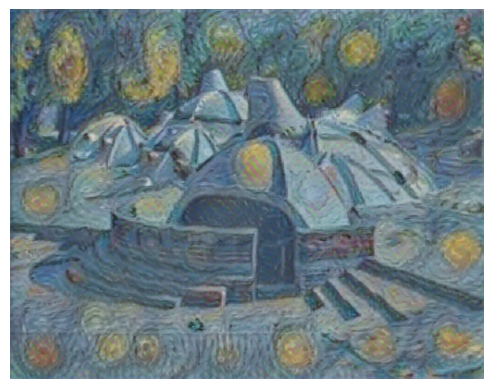

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import numpy as np

# Helper function to load and resize images to fit the model
def load_and_process_image(image_path):
    max_dim = 512
    # Load the image from the file path
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    # Scale the image down so the model doesn't run out of memory
    shape = tf.cast(tf.shape(img)[:-1], tf.float32)
    long_dim = max(shape)
    scale = max_dim / long_dim

    new_shape = tf.cast(shape * scale, tf.int32)
    img = tf.image.resize(img, new_shape)
    img = img[tf.newaxis, :]
    return img

def apply_style(content_path, style_path):
    print("Loading your images...")
    content_image = load_and_process_image(content_path)
    style_image = load_and_process_image(style_path)

    # Download/Load the pre-trained Neural Style Transfer model from TF Hub
    print("Loading the pre-trained VGG-based model (this takes a few seconds)...")
    model_url = 'https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2'
    hub_model = hub.load(model_url)

    # Pass both images into the model to generate the new artwork
    print("Painting your new image...")
    stylized_image = hub_model(tf.constant(content_image), tf.constant(style_image))[0]

    # Show the final generated image on your screen
    print("Done! Displaying the result...")
    plt.imshow(np.squeeze(stylized_image))
    plt.axis('off')
    plt.show()

# --- MAIN EXECUTION ---
# Ensure you have two images saved in the exact same folder as this script!
content_photo = "photo.jpg"  # Replace with your photograph's file name
style_painting = "painting.jpg" # Replace with your artwork's file name

apply_style(content_photo, style_painting)